# CS106 — Basics of Machine Learning & Applications
## Student Burnout / Academic Stress Predictor
**Dataset:** Student Mental Health & Burnout (Kaggle)  
**Goal:** Predict whether a student is at High Burnout Risk using lifestyle and academic features.  
**Models Compared:** Logistic Regression, Decision Tree, Random Forest, KNN, SVM

---
## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.impute           import SimpleImputer

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
os.makedirs("outputs", exist_ok=True)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


---
## Step 2 — Load Dataset & Initial Exploration

In [2]:
df = pd.read_csv("data/student_mental_health_burnout.csv")

print("Shape          :", df.shape)
print("Columns        :", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape          : (150000, 20)
Columns        : ['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'stress_level', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'sleep_quality', 'attendance_percentage', 'cgpa', 'internet_quality', 'burnout_level']

First 5 rows:


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64


In [4]:
print("Descriptive Statistics:")
df.describe().round(2)

Descriptive Statistics:


,student_id,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00
mean,175000.50,21.00,5.51,6.50,6.50,5.49,5.50,5.51,5.50,5.52,1.00,75.01,7.00
std,43301.41,2.58,2.60,1.44,3.18,2.87,2.87,2.88,2.86,2.87,0.58,14.41,1.73
min,100001.00,17.00,1.00,4.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,50.00,4.00
25%,137500.75,19.00,3.30,5.20,3.70,3.00,3.00,3.00,3.00,3.00,0.50,62.50,5.50
50%,175000.50,21.00,5.50,6.50,6.50,5.00,5.00,6.00,6.00,6.00,1.00,75.00,6.99
75%,212500.25,23.00,7.70,7.70,9.30,8.00,8.00,8.00,8.00,8.00,1.50,87.50,8.50
max,250000.00,25.00,10.00,9.00,12.00,10.00,10.00,10.00,10.00,10.00,2.00,100.00,10.00


---
## Step 3 — Create Target Label (BurnoutRisk)
> `burnout_level = High` → **1 (High Risk)**  
> `burnout_level = Medium or Low` → **0 (Low Risk)**

In [5]:
df["BurnoutRisk"] = df["burnout_level"].str.strip().str.lower().map({
    "low"   : 0,
    "medium": 0,
    "high"  : 1
})

print("Class distribution:")
print(df["BurnoutRisk"].value_counts())
print("\nClass balance (%):")
print(df["BurnoutRisk"].value_counts(normalize=True).round(3) * 100)

Class distribution:
BurnoutRisk
0    100234
1     49766
Name: count, dtype: int64

Class balance (%):
BurnoutRisk
0    66.8
1    33.2
Name: proportion, dtype: float64


In [6]:
features = [
    "daily_sleep_hours",
    "daily_study_hours",
    "screen_time_hours",
    "attendance_percentage",
    "academic_pressure_score",
    "physical_activity_hours",
    "social_support_score"
]

X = df[features].apply(pd.to_numeric, errors="coerce")
y = df["BurnoutRisk"]

print("Feature matrix shape:", X.shape)
print("Target vector shape :", y.shape)

Feature matrix shape: (150000, 7)
Target vector shape : (150000,)


---
## Step 4 — Exploratory Data Analysis (EDA)

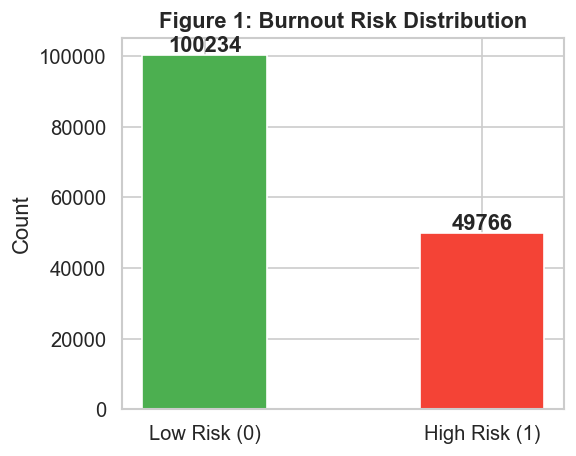

Saved: outputs/fig1_class_distribution.png


In [7]:
# Figure 1 — Class Distribution
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["BurnoutRisk"].value_counts().sort_index()
bars = ax.bar(["Low Risk (0)", "High Risk (1)"], counts,
              color=["#4CAF50", "#F44336"], edgecolor="white", width=0.45)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, str(c),
            ha="center", va="bottom", fontweight="bold")
ax.set_title("Figure 1: Burnout Risk Distribution", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/fig1_class_distribution.png")
plt.show()
print("Saved: outputs/fig1_class_distribution.png")

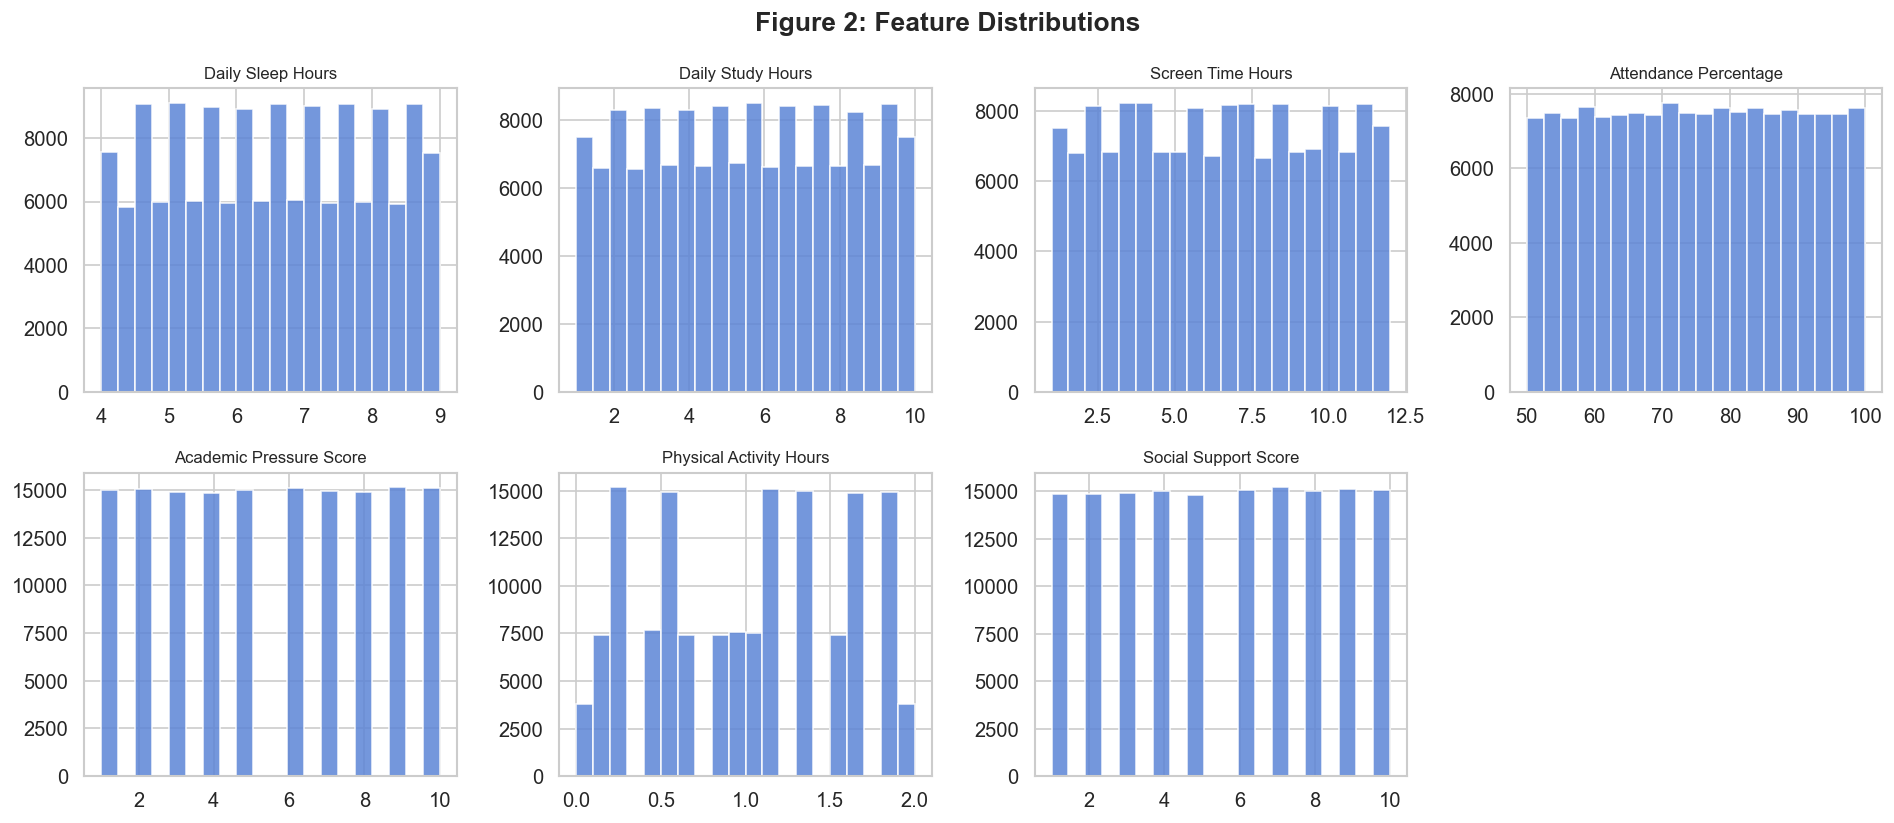

Saved: outputs/fig2_feature_histograms.png


In [8]:
# Figure 2 — Feature Histograms
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Figure 2: Feature Distributions", fontweight="bold")
for ax, col in zip(axes.flatten(), features):
    ax.hist(X[col].dropna(), bins=20, color="#5C85D6", edgecolor="white", alpha=0.85)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/fig2_feature_histograms.png")
plt.show()
print("Saved: outputs/fig2_feature_histograms.png")

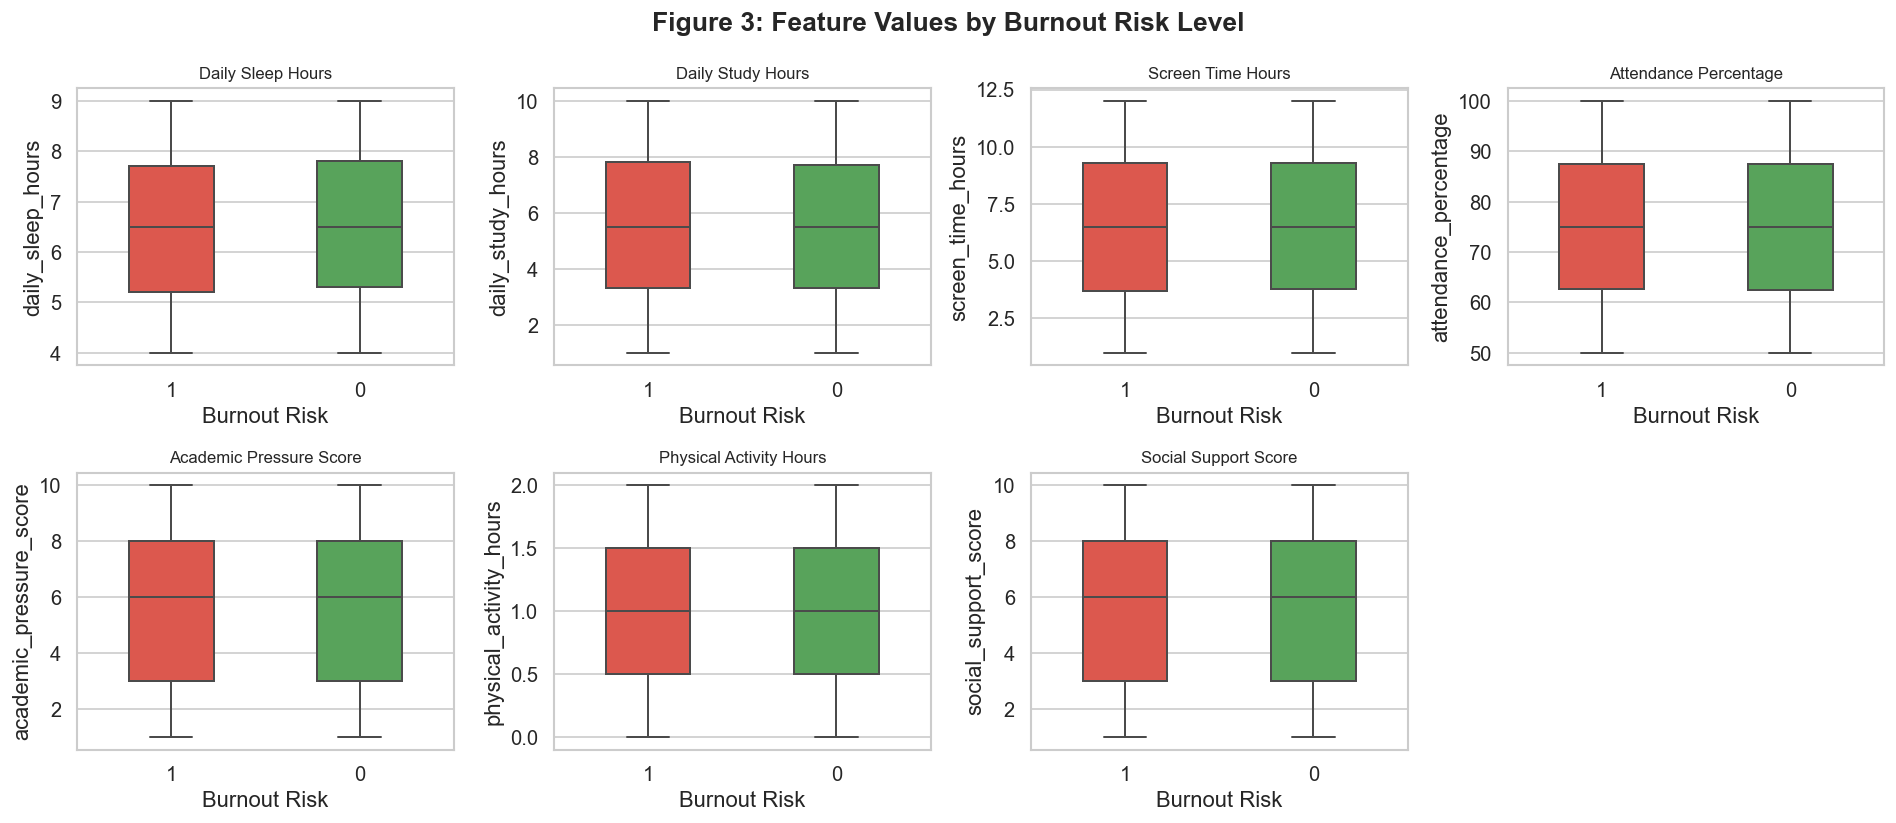

Saved: outputs/fig3_boxplots.png


In [9]:
# Figure 3 — Boxplots by Burnout Risk
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Figure 3: Feature Values by Burnout Risk Level", fontweight="bold")
plot_df = X.copy()
plot_df["BurnoutRisk"] = y.values.astype(str)
palette = {"0": "#4CAF50", "1": "#F44336"}

for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data=plot_df, x="BurnoutRisk", y=col,
                hue="BurnoutRisk", palette=palette,
                ax=ax, width=0.45, linewidth=1.2, legend=False)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("Burnout Risk")
axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/fig3_boxplots.png")
plt.show()
print("Saved: outputs/fig3_boxplots.png")

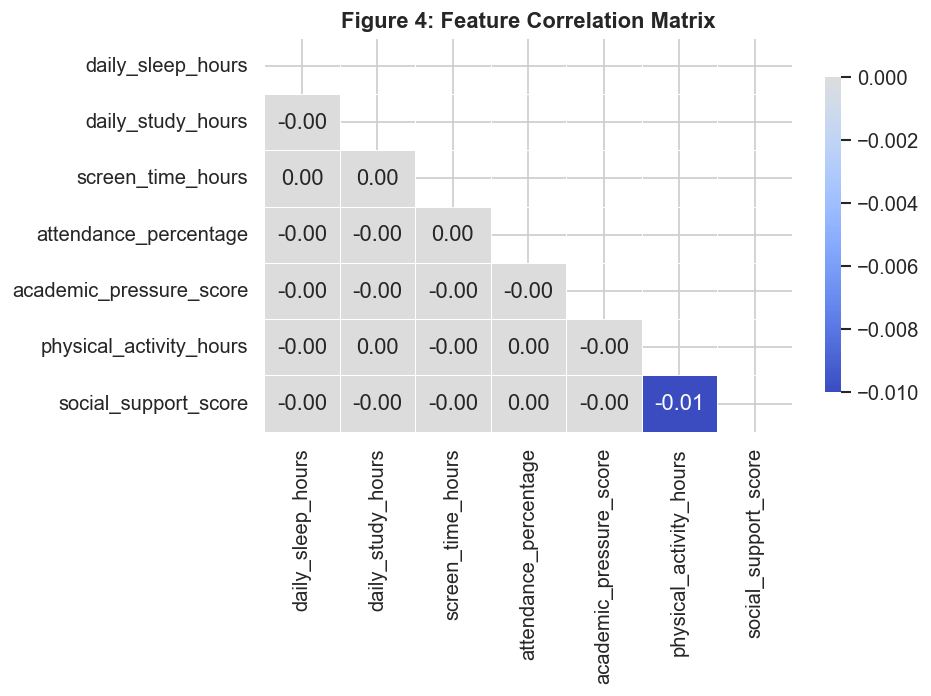

Saved: outputs/fig4_correlation_heatmap.png


In [10]:
# Figure 4 — Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = X.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Figure 4: Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/fig4_correlation_heatmap.png")
plt.show()
print("Saved: outputs/fig4_correlation_heatmap.png")

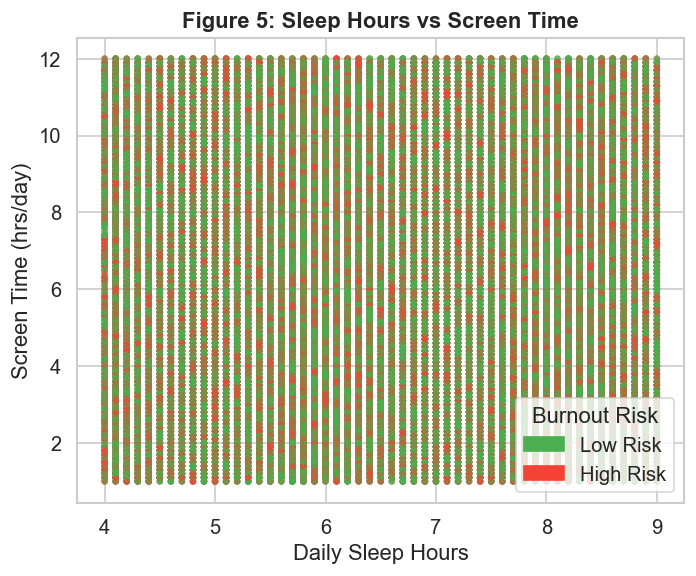

Saved: outputs/fig5_sleep_vs_screen.png

✓ All EDA figures saved to outputs/


In [11]:
# Figure 5 — Sleep vs Screen Time Scatter
fig, ax = plt.subplots(figsize=(6, 5))
color_map = plot_df["BurnoutRisk"].map({"0": "#4CAF50", "1": "#F44336"})
ax.scatter(plot_df["daily_sleep_hours"], plot_df["screen_time_hours"],
           c=color_map, alpha=0.4, s=15, edgecolors="none")
ax.legend(handles=[
    mpatches.Patch(color="#4CAF50", label="Low Risk"),
    mpatches.Patch(color="#F44336", label="High Risk")
], title="Burnout Risk")
ax.set_title("Figure 5: Sleep Hours vs Screen Time", fontweight="bold")
ax.set_xlabel("Daily Sleep Hours")
ax.set_ylabel("Screen Time (hrs/day)")
plt.tight_layout()
plt.savefig("outputs/fig5_sleep_vs_screen.png")
plt.show()
print("Saved: outputs/fig5_sleep_vs_screen.png")
print("\n✓ All EDA figures saved to outputs/")

---
## Step 5 — Preprocessing
> - Train/test split first (80/20) with stratify to preserve class balance  
> - Median imputation for missing values (no data loss)  
> - StandardScaler to normalise feature ranges (critical for KNN, SVM, LR)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Impute missing values with column median
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=features)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=features)

# Scale features to same range
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train_sc.shape}")
print(f"Test set     : {X_test_sc.shape}")
print("\n✓ Preprocessing complete")

Training set : (120000, 7)
Test set     : (30000, 7)

✓ Preprocessing complete


---
## Step 6 — Train 5 Models & Compare

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN"                : KNeighborsClassifier(n_neighbors=5),
    "SVM"                : SVC(probability=True, random_state=42)
}

results       = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    if name in ["Decision Tree", "Random Forest"]:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]

    trained_models[name] = (model, y_pred, y_prob)
    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred,    zero_division=0), 4),
        "F1 Score" : round(f1_score(y_test, y_pred,        zero_division=0), 4),
    })
    print("done")

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
print("\n" + "=" * 62)
print("MODEL COMPARISON TABLE")
print("=" * 62)
print(results_df.to_string(index=False))
results_df.to_csv("outputs/model_comparison.csv", index=False)
print("\n✓ Saved: outputs/model_comparison.csv")

Training Logistic Regression... done
Training Decision Tree... done
Training Random Forest... done
Training KNN... done
Training SVM... 

In [ ]:
best_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_name}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, trained_models[best_name][1]))

---
## Step 7 — Result Visualisations

In [ ]:
# Figure 6 — Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(results_df))
width   = 0.2
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
colors  = ["#5C85D6", "#4CAF50", "#FF9800", "#F44336"]
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width,
           label=metric, color=color, alpha=0.85, edgecolor="white")
ax.set_title("Figure 6: Model Comparison", fontweight="bold")
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig("outputs/fig6_model_comparison.png")
plt.show()
print("Saved: outputs/fig6_model_comparison.png")

In [ ]:
# Figure 7 — Confusion Matrix for Best Model
_, y_pred_best, _ = trained_models[best_name]
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Risk", "High Risk"],
            yticklabels=["Low Risk", "High Risk"],
            linewidths=0.5, ax=ax)
ax.set_title(f"Figure 7: Confusion Matrix — {best_name}", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/fig7_confusion_matrix.png")
plt.show()
print("Saved: outputs/fig7_confusion_matrix.png")

In [ ]:
# Figure 8 — ROC Curves (all models)
fig, ax = plt.subplots(figsize=(7, 5))
line_colors = ["#5C85D6", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"]
for (name, (model, _, y_prob)), color in zip(trained_models.items(), line_colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})", color=color, linewidth=1.8)
ax.plot([0,1],[0,1], "k--", linewidth=1, alpha=0.4)
ax.set_title("Figure 8: ROC Curves — All Models", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/fig8_roc_curves.png")
plt.show()
print("Saved: outputs/fig8_roc_curves.png")

In [ ]:
# Figure 9 — Feature Importance (Random Forest)
rf_model = trained_models["Random Forest"][0]
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", ax=ax, color="#5C85D6", edgecolor="white")
ax.set_title("Figure 9: Feature Importance — Random Forest", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("outputs/fig9_feature_importance.png")
plt.show()
print("Saved: outputs/fig9_feature_importance.png")

---
## Step 8 — Predict for a New Student
> Enter any student's details below to get a burnout risk prediction.

In [ ]:
new_student = pd.DataFrame([{
    "daily_sleep_hours"      : 4,
    "daily_study_hours"      : 9,
    "screen_time_hours"      : 8,
    "attendance_percentage"  : 65,
    "academic_pressure_score": 8,
    "physical_activity_hours": 0.5,
    "social_support_score"   : 2
}])

best_model = trained_models[best_name][0]
if best_name in ["Decision Tree", "Random Forest"]:
    pred = best_model.predict(new_student)[0]
    prob = best_model.predict_proba(new_student)[0][1]
else:
    ns_imputed = imputer.transform(new_student)
    ns_sc      = scaler.transform(ns_imputed)
    pred = best_model.predict(ns_sc)[0]
    prob = best_model.predict_proba(ns_sc)[0][1]

print("=" * 40)
print("PREDICTION FOR NEW STUDENT")
print("=" * 40)
print(f"Model used         : {best_name}")
print(f"Burnout Risk Label : {'HIGH RISK' if pred == 1 else 'LOW RISK'}")
print(f"Burnout Probability: {prob:.2%}")
print("\n✓ All outputs saved to outputs/")
print("  Figures 1-9 are ready for your List of Figures section.")